In [12]:
# Keep track of updated packages
%load_ext autoreload
%autoreload 2


# Select a voxel in dMRI space
# Find corresponding slices 
# Check everyting

# Usual suspects
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import os
from fsl.data.image import Image

# Imports from cmc_hybrid
from cmc_hybrid import utils, fod
from cmc_hybrid import coordinate_mapping as cm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
def load_bpx(bpxdir):
    ths = [Image(x).data for x in sorted(glob(os.path.join(bpxdir,'merged_th?samples.nii.gz')))]
    phs = [Image(x).data for x in sorted(glob(os.path.join(bpxdir,'merged_ph?samples.nii.gz')))]
    fs =  [Image(x).data for x in sorted(glob(os.path.join(bpxdir,'merged_f?samples.nii.gz')))]

    return ths, phs, fs

def get_bpx_voxel(vox, ths, phs, fs, outtype='angles'):
    x,y,z      = vox
    th_samples = np.array([th[x,y,z,:] for th in ths]).flatten()
    ph_samples = np.array([ph[x,y,z,:] for ph in phs]).flatten()
    f_samples  = np.array([f[x,y,z,:] for f in fs]).flatten()

    if outtype == 'angles':
        return th_samples, ph_samples, f_samples
    if outtype == 'vectors':
        ct,st,cp,sp=np.cos(th_samples),np.sin(th_samples),np.cos(ph_samples),np.sin(ph_samples)
        v = np.array([st*cp,st*sp,ct]).T
        return v, f_samples
    if outtype == 'SH':
        SH  = fod.form_SHmat([th_samples, ph_samples], max_order=8)
        def lsqL2(A, y, lamb=1e-10):
            U,S,Vt = np.linalg.svd(A, full_matrices=False)
            return Vt.T@((U.T@y)*(S/(S**2+lamb)))
        fod_coeffs = lsqL2(SH, f_samples, 1e0)

        return fod_coeffs
    

    

In [14]:
# Helper functions for this Notebook
def slide_to_deck(theta, slide_index, slides, slide_deck):
    all_v = []
    for sl, angles in zip(slide_index, theta):
        # if len(angles)==0:
        #     continue
        angles = utils.fudge_psoct_orientation(angles)
        # slide deck -> slide re-orientation
        F = slides[sl].getAffine('world', 'voxel')[:3,:3] @ slide_deck.getAffine('voxel', 'world')[:3,:3]
        v = np.stack([np.cos(angles), np.zeros_like(angles), np.sin(angles)], axis=0)
        v = np.linalg.inv(F)@v
        v /= np.linalg.norm(v, axis=0, keepdims=True)
        all_v.append(v)
    all_v = np.concatenate(all_v,axis=1)
    return all_v

def FOD_from_samples(A, nbins, weights=None):
    """Histogram (FOD) of orientations in A (2-D)."""
    if A.ndim > 2:
        A = A.reshape(-1, A.shape[-1])
    thetas = np.linspace(-np.pi, np.pi, nbins)
    counts = np.zeros_like(thetas)
    A0 = np.stack((np.cos(thetas), np.sin(thetas)), axis=1)
    w  = 1.
    from scipy.spatial import KDTree
    tree = KDTree(A0)
    _, ii = tree.query(A, k=1)        
    counts += np.bincount(ii, minlength=len(counts),weights=weights)
    _, ii = tree.query(-A, k=1)              # antipodal    
    counts += np.bincount(ii, minlength=len(counts),weights=weights)
    return counts, thetas

def plot_FOD(bins, counts, ax=None):
    if ax is None:
        ax = plt.subplot(111, projection='polar')
    if isinstance(counts, list):
        for c in counts:
            ax.plot(bins, c)
    else:
        ax.plot(bins, counts)
    ax.set_yticks([]), ax.set_xticks([])


def plot_FOD_from_samples(A, nbins=101, ax=None, weights=None):
    counts, bins = FOD_from_samples(A, nbins,weights)
    plot_FOD(bins, counts, ax)


In [ ]:
# bpxdir   = '/Users/saad/data/CMC/Moe_bpx/data.bedpostX_SSFP'
# ori_psoctdir = '/Users/saad/data/CMC/PSOCT/Moe/Orientation/lowres'
# ret_psoctdir = '/Users/saad/data/CMC/PSOCT/Moe/Retardance/lowres'
# regdir   = '/Users/saad/data/CMC/Registration'

bpxdir   = '/Users/Vasilis/Downloads/CMC_results/data.bedpostX_SSFP'
ori_psoctdir = '/Users/Vasilis/Downloads/CMC_results/Moe_flirt_Cross_nl/Orientation/lowres'
ret_psoctdir = '/Users/Vasilis/Downloads/CMC_results/Moe_flirt_Cross_nl/Retardance/lowres'
regdir   = '/Users/Vasilis/Downloads/CMC_results/Moe_flirt_Cross_nl'

# Volume in DTI
volume = Image(bpxdir+'/mean_f1samples')

# PSOCT slides
slide_files = sorted(glob(ori_psoctdir+'/Slice_???_EnAO_downsample_10_hdr.nii.gz'))

slides = [Image(sl) for sl in slide_files]

slide_deck = Image(regdir+'/Ori_slide_deck')

vol2slide  = regdir+'/MRI_to_PSOCT_warpfield.nii.gz'
slide2vol  = regdir+'/PSOCT_to_MRI_warpfield.nii.gz'

from fsl.transform.fnirt import readFnirt
vol2slide = readFnirt(vol2slide, volume, slide_deck)
slide2vol = readFnirt(slide2vol, slide_deck, volume)


In [16]:
# Here - run the stuff that takes a while to run (like loading bpx samples and warpfields)
t_ = utils.Time()
t_.tic()
# Load bpx
# bpxdir = '/Users/saad/data/CMC/Moe_bpx/data.bedpostX_SSFP'
ths, phs, fs = load_bpx(bpxdir)

# Load warps
slide2vol.transform([0,0,0], 'voxel', 'world')
vol2slide.transform([0,0,0], 'world', 'voxel')
# Calc Jacobian
jx, jy, jz = [np.gradient(vol2slide.data[...,i]) for i in range(3)]

t_.toc()

Elapsed time : 172.8301 seconds.


In [17]:
# Select a voxel
# vox_diff = [168, 161, 61]   # left-right
# vox_diff = [151, 180, 50]   # up-down (left hemi)
vox_diff = [194, 180, 52]   # up-down (right hemi)
# vox_diff = [185, 147, 52]   # splenium (right hemi)

slide_mapping = regdir + '/slidedeck_slice_mapping.json'

# Get PSOCT orientations
pixgrid, voxgrid, slide_index, theta, _ = cm.vox_to_pix_slidedeck(vox_diff, volume, ori_psoctdir, ret_psoctdir, slide_deck, slide_mapping, slide2vol=slide2vol, vol2slide=vol2slide)
# Get BPX orientations
v_samples, f_samples = get_bpx_voxel(vox_diff, ths, phs, fs, outtype='vectors')


In [18]:
# Transformations
# Nonlinear Jacobian at this voxel
Jw = [[jx[0][vox_diff[0], vox_diff[1], vox_diff[2]], jy[0][vox_diff[0], vox_diff[1], vox_diff[2]], jz[0][vox_diff[0], vox_diff[1], vox_diff[2]]],
      [jx[1][vox_diff[0], vox_diff[1], vox_diff[2]], jy[1][vox_diff[0], vox_diff[1], vox_diff[2]], jz[1][vox_diff[0], vox_diff[1], vox_diff[2]]], 
      [jx[2][vox_diff[0], vox_diff[1], vox_diff[2]], jy[2][vox_diff[0], vox_diff[1], vox_diff[2]], jz[2][vox_diff[0], vox_diff[1], vox_diff[2]]]]

# dMRI -> slide deck re-orientation
F1 = np.eye(3) + Jw

# Transform to deck-space
v_samples_deck = F1@v_samples.T
v_samples_deck /= np.linalg.norm(v_samples_deck, axis=0, keepdims=True)

all_v          = slide_to_deck(theta, slide_index, slides, slide_deck)


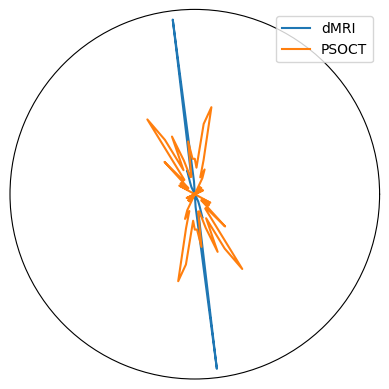

In [19]:
# Visualise in 2D
plot_FOD_from_samples(np.stack([v_samples_deck[0], v_samples_deck[2]], axis=1), weights=f_samples)
plot_FOD_from_samples(np.stack([all_v[0], all_v[2]], axis=1))
plt.legend(['dMRI', 'PSOCT'])
plt.show()


In [20]:
# Visualise in 3D

coeff_dmri, skde  = fod.fit_sh_fod(all_v.T, max_order=8, 
                                   symmetric=True,
                                   normalise=True, output_kde=True, kde_bw=100)

v_samples_deck = F1@v_samples.T

samples = v_samples_deck.T #np.concatenate([v_samples,-v_samples])
fig = fod.plot_odf_glyph(skde, glyph=False, samples=samples)
fig.update_traces(marker=dict(color=f_samples,size=3), selector=dict(type="scatter3d"))
fig.show()



In [38]:
# jx_deck, jy_deck, jz_deck = [np.gradient(slide2vol.data[...,i]) for i in range(3)]

# Jw_deck = [[jx_deck[0][vox_diff[0], vox_diff[1], vox_diff[2]], jy_deck[0][vox_diff[0], vox_diff[1], vox_diff[2]], jz_deck[0][vox_diff[0], vox_diff[1], vox_diff[2]]],
#       [jx_deck[1][vox_diff[0], vox_diff[1], vox_diff[2]], jy_deck[1][vox_diff[0], vox_diff[1], vox_diff[2]], jz_deck[1][vox_diff[0], vox_diff[1], vox_diff[2]]], 
#       [jx_deck[2][vox_diff[0], vox_diff[1], vox_diff[2]], jy_deck[2][vox_diff[0], vox_diff[1], vox_diff[2]], jz_deck[2][vox_diff[0], vox_diff[1], vox_diff[2]]]]

# # slide deck -> dMRI re-orientation
# F1_deck = np.eye(3) + Jw_deck

# Transform to dMRI space: np.linalg.inv(F1) = slide deck -> dMRI re-orientation
all_v_dmri = np.linalg.inv(F1)@all_v
all_v_dmri /= np.linalg.norm(all_v_dmri, axis=0, keepdims=True)

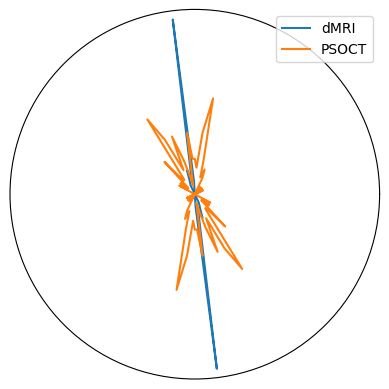

In [39]:
# try showing results in DTI space

# Visualise in 2D
plot_FOD_from_samples(np.stack([v_samples.T[0], v_samples.T[2]], axis=1), weights=f_samples)
plot_FOD_from_samples(np.stack([all_v_dmri[0], all_v_dmri[2]], axis=1))
plt.legend(['dMRI', 'PSOCT'])
plt.show()

